In [2]:
import os
import shutil
import librosa
import numpy as np
from pathlib import Path
from collections import defaultdict

ROOT = r'C:\Users\HP\Downloads\Foss_hack\Data-Pool-Bio-Acoustics-\audio'
OUTPUT = r'C:\Users\HP\Downloads\Foss_hack\cleaned_audio'

CLASSES = [
    'Duttaphrynus_melanostictus',
    'Euphlyctis_cyanophlyctis',
    'Hoplobatrachus_tigerinus',
    'Microhyla_ornata',
    'Polypedates_maculatus',
]

SUPPORTED = {'.wav', '.mp3', '.m4a', '.mpga'}
FORMAT_PRIORITY = {'.wav': 0, '.mp3': 1, '.m4a': 2, '.mpga': 3}

# ── Step 1: Remove cross-class contamination ─────────────────────────
def is_contaminated(filename, expected_class):
    fname = filename.lower()
    for cls in CLASSES:
        if cls.lower() == expected_class.lower():
            continue
        # check if another species name is in the filename
        species_word = cls.split('_')[1].lower()  # e.g. 'melanostictus'
        if species_word in fname:
            return True, cls
    return False, None

# ── Step 2: Deduplicate by duration + content hash ───────────────────
def get_duration(path):
    try:
        y, sr = librosa.load(str(path), sr=None, mono=True)
        return round(librosa.get_duration(y=y, sr=sr), 2)
    except:
        return None

def pick_best(file_list):
    # prefer wav > mp3 > m4a > mpga, then shortest filename
    return sorted(file_list,
                  key=lambda f: (FORMAT_PRIORITY.get(f.suffix.lower(), 9),
                                 len(f.name)))[0]

# ── Main cleaning logic ───────────────────────────────────────────────
def clean_dataset(root, output):
    root = Path(root)
    output = Path(output)
    output.mkdir(parents=True, exist_ok=True)

    grand_total_removed_contam = 0
    grand_total_removed_dedup  = 0
    grand_total_kept           = 0

    print("=" * 65)
    print("  DATASET CLEANING REPORT")
    print("=" * 65)

    for cls in CLASSES:
        src_dir = root / cls
        dst_dir = output / cls
        dst_dir.mkdir(parents=True, exist_ok=True)

        if not src_dir.exists():
            print(f"\n[!] Folder not found: {cls}")
            continue

        all_files = [f for f in src_dir.iterdir()
                     if f.suffix.lower() in SUPPORTED]

        contaminated = []
        clean_files  = []

        # ── Pass 1: contamination filter
        for f in all_files:
            poisoned, culprit = is_contaminated(f.name, cls)
            if poisoned:
                contaminated.append((f, culprit))
            else:
                clean_files.append(f)

        # ── Pass 2: deduplicate by duration
        duration_groups = defaultdict(list)
        corrupt = []

        for f in clean_files:
            dur = get_duration(f)
            if dur is None:
                corrupt.append(f)
            elif dur < 1.0:
                corrupt.append(f)   # too short, discard
            else:
                duration_groups[dur].append(f)

        kept   = []
        deduped = []

        for dur, group in duration_groups.items():
            if len(group) == 1:
                kept.append(group[0])
            else:
                best = pick_best(group)
                kept.append(best)
                deduped.extend([f for f in group if f != best])

        # ── Copy kept files to output
        for f in kept:
            shutil.copy2(f, dst_dir / f.name)

        # ── Estimate 3s clips from kept files
        total_dur = 0
        for f in kept:
            d = get_duration(f)
            if d:
                total_dur += d
        clips_est = int(total_dur // 3)

        # ── Report
        print(f"\n  CLASS: {cls}")
        print(f"  {'-'*55}")
        print(f"  Original files:       {len(all_files)}")
        print(f"  Contaminated removed: {len(contaminated)}")
        if contaminated:
            for f, culprit in contaminated:
                print(f"    [-] {f.name}  (belongs to {culprit})")
        print(f"  Duplicates removed:   {len(deduped)}")
        if deduped:
            for f in deduped:
                print(f"    [-] {f.name}")
        print(f"  Corrupt/too short:    {len(corrupt)}")
        if corrupt:
            for f in corrupt:
                print(f"    [-] {f.name}")
        print(f"  Files kept:           {len(kept)}")
        print(f"  Total duration:       {total_dur:.1f}s ({total_dur/60:.1f} min)")
        print(f"  Estimated 3s clips:   {clips_est}")

        grand_total_removed_contam += len(contaminated)
        grand_total_removed_dedup  += len(deduped)
        grand_total_kept           += len(kept)

    print("\n" + "=" * 65)
    print("  CLEANING SUMMARY")
    print("=" * 65)
    print(f"  Contaminated files removed:  {grand_total_removed_contam}")
    print(f"  Duplicate files removed:     {grand_total_removed_dedup}")
    print(f"  Total clean files kept:      {grand_total_kept}")
    print(f"\n  Clean dataset saved to: {output}")
    print("=" * 65)


if __name__ == "__main__":
    clean_dataset(ROOT, OUTPUT)

  DATASET CLEANING REPORT


C:\Users\HP\AppData\Local\Temp\ipykernel_11296\4060265230.py:37: UserWarning: PySoundFile failed. Trying audioread instead.
  y, sr = librosa.load(str(path), sr=None, mono=True)
c:\Users\HP\Downloads\Foss_hack\Data-Pool-Bio-Acoustics-\.venv\lib\site-packages\librosa\core\audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)



  CLASS: Duttaphrynus_melanostictus
  -------------------------------------------------------
  Original files:       171
  Contaminated removed: 0
  Duplicates removed:   58
    [-] 10_911642.mp3
    [-] Duttaphrynus_melanostictus_88.wav
    [-] duttaphrynus_melanostictus_911642.mp3
    [-] gbif_4906817341.wav
    [-] 11_925665.mp3
    [-] duttaphrynus_melanostictus_925665.mp3
    [-] XC925665 - Southeast Asian Toad - Duttaphrynus melanostictus.wav
    [-] 1_1082727.mp3
    [-] duttaphrynus_melanostictus_1082727.mp3
    [-] duttaphrynus_melanostictus_1076709.mp3
    [-] 3_1076705.mp3
    [-] duttaphrynus_melanostictus_1076705.mp3
    [-] duttaphrynus_melanostictus_1048092.mp3
    [-] XC1048092 - Southeast Asian Toad - Duttaphrynus melanostictus.mp3
    [-] duttaphrynus_melanostictus_994893.mp3
    [-] XC994893 - Southeast Asian Toad - Duttaphrynus melanostictus.mp3
    [-] 6_928661.mp3
    [-] duttaphrynus_melanostictus_928661.mp3
    [-] 7_928658.mp3
    [-] duttaphrynus_melanostict

In [1]:
import os
import random
import librosa
import numpy as np
import soundfile as sf
from pathlib import Path

CLEANED   = r'C:\Users\HP\Downloads\Foss_hack\cleaned_audio'
OUTPUT    = r'C:\Users\HP\Downloads\Foss_hack\prepared_audio'
TARGET    = 100
SR        = 22050
CLIP_DUR  = 3.0
SEED      = 42
SUPPORTED = {'.wav', '.mp3', '.m4a', '.mpga'}

random.seed(SEED)
np.random.seed(SEED)

CLASSES = [
    'Duttaphrynus_melanostictus',
    'Euphlyctis_cyanophlyctis',
    'Hoplobatrachus_tigerinus',
    'Microhyla_ornata',
    'Polypedates_maculatus',
]

# ── Augmentation helpers ──────────────────────────────────────────────
def aug_time_stretch(y):
    rate = np.random.uniform(0.85, 1.15)
    return librosa.effects.time_stretch(y, rate=rate)

def aug_pitch_shift(y, sr):
    steps = np.random.uniform(-2, 2)
    return librosa.effects.pitch_shift(y, sr=sr, n_steps=steps)

def aug_add_noise(y):
    noise = np.random.randn(len(y)) * 0.004
    return np.clip(y + noise, -1.0, 1.0)

AUGMENTORS = [aug_time_stretch,
              lambda y: aug_pitch_shift(y, SR),
              aug_add_noise]

# ── Slice audio into fixed-length clips ───────────────────────────────
def slice_audio(path, sr=SR, clip_dur=CLIP_DUR):
    y, _ = librosa.load(str(path), sr=sr, mono=True)
    clip_len = int(clip_dur * sr)
    clips = []
    for start in range(0, len(y) - clip_len + 1, clip_len):
        clips.append(y[start:start + clip_len])
    return clips

# ── Main pipeline ─────────────────────────────────────────────────────
def prepare(cleaned_root, output_root):
    cleaned_root = Path(cleaned_root)
    output_root  = Path(output_root)

    print("=" * 65)
    print("  PREPARE DATASET — SLICE + BALANCE")
    print("=" * 65)

    all_clips_info = []   # (class_name, clip_array) for final split

    for cls in CLASSES:
        src_dir = cleaned_root / cls
        dst_dir = output_root / cls
        dst_dir.mkdir(parents=True, exist_ok=True)

        audio_files = [f for f in src_dir.iterdir()
                       if f.suffix.lower() in SUPPORTED]

        # ── Slice all files into 3s clips
        all_clips = []
        for f in audio_files:
            try:
                clips = slice_audio(f)
                all_clips.extend(clips)
            except Exception as e:
                print(f"  [!] Failed to slice {f.name}: {e}")

        print(f"\n  {cls}")
        print(f"  Raw 3s clips from slicing: {len(all_clips)}")

        # ── Augment if below target
        aug_count = 0
        while len(all_clips) < TARGET:
            src_clip = random.choice(all_clips)
            aug_fn   = random.choice(AUGMENTORS)
            try:
                augmented = aug_fn(src_clip.copy())
                clip_len  = int(CLIP_DUR * SR)
                # ensure exact length after time stretch
                if len(augmented) >= clip_len:
                    all_clips.append(augmented[:clip_len])
                    aug_count += 1
            except:
                pass

        if aug_count:
            print(f"  Augmented clips added:     {aug_count}")

        # ── Subsample to TARGET
        selected = random.sample(all_clips, TARGET)
        print(f"  Final clips kept:          {len(selected)} (target={TARGET})")

        # ── Save as wav files
        for i, clip in enumerate(selected):
            out_path = dst_dir / f"{cls}_clip_{i:04d}.wav"
            sf.write(str(out_path), clip, SR)

        all_clips_info.append((cls, len(selected)))

    # ── Final summary
    print("\n" + "=" * 65)
    print("  FINAL SUMMARY")
    print("=" * 65)
    total = 0
    for cls, n in all_clips_info:
        print(f"  {cls:<40} {n} clips")
        total += n
    print(f"\n  Total clips ready:  {total}")
    print(f"  Output folder:      {output_root}")
    print("=" * 65)
    print("\n  Next step: run mel_spectrogram.py to extract features")


if __name__ == "__main__":
    prepare(CLEANED, OUTPUT)

  PREPARE DATASET — SLICE + BALANCE


C:\Users\HP\AppData\Local\Temp\ipykernel_14480\1069535106.py:46: UserWarning: PySoundFile failed. Trying audioread instead.
  y, _ = librosa.load(str(path), sr=sr, mono=True)
c:\Users\HP\Downloads\Foss_hack\Data-Pool-Bio-Acoustics-\.venv\lib\site-packages\librosa\core\audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)



  Duttaphrynus_melanostictus
  Raw 3s clips from slicing: 777
  Final clips kept:          100 (target=100)

  Euphlyctis_cyanophlyctis
  Raw 3s clips from slicing: 136
  Final clips kept:          100 (target=100)

  Hoplobatrachus_tigerinus
  Raw 3s clips from slicing: 275
  Final clips kept:          100 (target=100)

  Microhyla_ornata
  Raw 3s clips from slicing: 89
  Augmented clips added:     11
  Final clips kept:          100 (target=100)


C:\Users\HP\AppData\Local\Temp\ipykernel_14480\1069535106.py:46: UserWarning: PySoundFile failed. Trying audioread instead.
  y, _ = librosa.load(str(path), sr=sr, mono=True)
c:\Users\HP\Downloads\Foss_hack\Data-Pool-Bio-Acoustics-\.venv\lib\site-packages\librosa\core\audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)



  Polypedates_maculatus
  Raw 3s clips from slicing: 93
  Augmented clips added:     7
  Final clips kept:          100 (target=100)

  FINAL SUMMARY
  Duttaphrynus_melanostictus               100 clips
  Euphlyctis_cyanophlyctis                 100 clips
  Hoplobatrachus_tigerinus                 100 clips
  Microhyla_ornata                         100 clips
  Polypedates_maculatus                    100 clips

  Total clips ready:  500
  Output folder:      C:\Users\HP\Downloads\Foss_hack\prepared_audio

  Next step: run mel_spectrogram.py to extract features


In [2]:
import os
import numpy as np
import librosa
from pathlib import Path

PREPARED = r'C:\Users\HP\Downloads\Foss_hack\prepared_audio'
FEATURES = r'C:\Users\HP\Downloads\Foss_hack\features'

SR        = 22050
N_MELS    = 128
N_FFT     = 2048
HOP_LEN   = 512
CLIP_DUR  = 3.0

CLASSES = [
    'Duttaphrynus_melanostictus',
    'Euphlyctis_cyanophlyctis',
    'Hoplobatrachus_tigerinus',
    'Microhyla_ornata',
    'Polypedates_maculatus',
]

CLASS_TO_IDX = {cls: i for i, cls in enumerate(CLASSES)}

def extract_mel(wav_path):
    y, sr = librosa.load(str(wav_path), sr=SR, mono=True)
    mel = librosa.feature.melspectrogram(
        y=y, sr=sr, n_mels=N_MELS,
        n_fft=N_FFT, hop_length=HOP_LEN
    )
    mel_db = librosa.power_to_db(mel, ref=np.max)
    # normalise to [0, 1]
    mel_db = (mel_db - mel_db.min()) / (mel_db.max() - mel_db.min() + 1e-6)
    return mel_db   # shape: (128, 130)

def extract_all(prepared_root, features_root):
    prepared_root = Path(prepared_root)
    features_root = Path(features_root)
    features_root.mkdir(parents=True, exist_ok=True)

    X, y = [], []

    print("=" * 65)
    print("  MEL SPECTROGRAM EXTRACTION")
    print("=" * 65)

    for cls in CLASSES:
        cls_dir = prepared_root / cls
        files   = sorted(cls_dir.glob("*.wav"))
        label   = CLASS_TO_IDX[cls]

        print(f"\n  {cls}  (label={label})")
        ok = 0
        for f in files:
            try:
                mel = extract_mel(f)
                X.append(mel)
                y.append(label)
                ok += 1
            except Exception as e:
                print(f"    [!] {f.name}: {e}")

        print(f"  Extracted: {ok}/{len(files)}")

    X = np.array(X, dtype=np.float32)   # (N, 128, 130)
    y = np.array(y, dtype=np.int64)     # (N,)

    # Add channel dim for CNN  →  (N, 1, 128, 130)
    X = X[:, np.newaxis, :, :]

    out_X = features_root / "X.npy"
    out_y = features_root / "y.npy"
    np.save(str(out_X), X)
    np.save(str(out_y), y)

    print("\n" + "=" * 65)
    print(f"  X shape : {X.shape}   (samples, channel, mels, time)")
    print(f"  y shape : {y.shape}")
    print(f"  Saved   : {out_X}")
    print(f"  Saved   : {out_y}")
    print("=" * 65)
    print("\n  Next step: run train_model.py")

if __name__ == "__main__":
    extract_all(PREPARED, FEATURES)

  MEL SPECTROGRAM EXTRACTION

  Duttaphrynus_melanostictus  (label=0)
  Extracted: 100/100

  Euphlyctis_cyanophlyctis  (label=1)
  Extracted: 100/100

  Hoplobatrachus_tigerinus  (label=2)
  Extracted: 100/100

  Microhyla_ornata  (label=3)
  Extracted: 100/100

  Polypedates_maculatus  (label=4)
  Extracted: 100/100

  X shape : (500, 1, 128, 130)   (samples, channel, mels, time)
  y shape : (500,)
  Saved   : C:\Users\HP\Downloads\Foss_hack\features\X.npy
  Saved   : C:\Users\HP\Downloads\Foss_hack\features\y.npy

  Next step: run train_model.py


In [5]:
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity

X = np.load(r"C:\Users\HP\Downloads\Foss_hack\features\X.npy")
y = np.load(r"C:\Users\HP\Downloads\Foss_hack\features\Y.npy")

# Flatten spectrograms
X_flat = X.reshape(X.shape[0], -1)

# Compute similarity matrix
sim_matrix = cosine_similarity(X_flat)

print(sim_matrix.shape)  # (500, 500)

(500, 500)


X shape: (500, 1, 128, 130)
y shape: (500,)
Similarity matrix shape: (500, 500)

================ RESULTS ================
Same class similarity   : 0.8973
Different class similarity: 0.8849

========== CLASS-WISE SIMILARITY ==========
Class 0: 0.8897
Class 1: 0.9312
Class 2: 0.8968
Class 3: 0.9070
Class 4: 0.8619


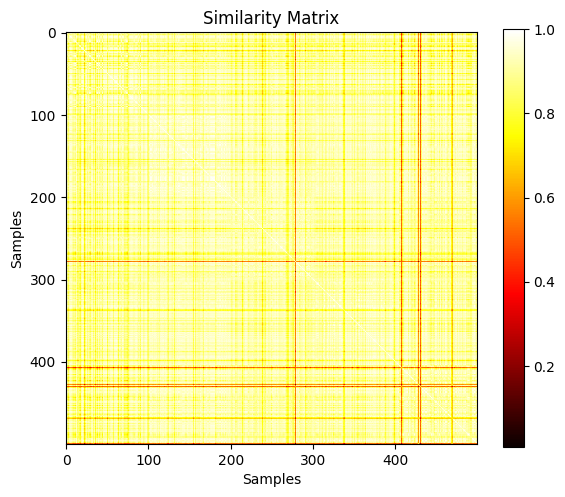

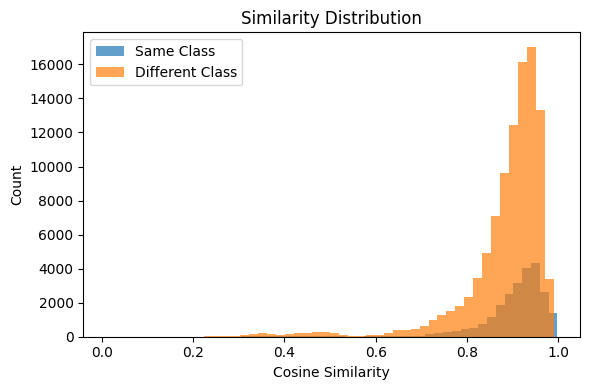

In [6]:
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity
import matplotlib.pyplot as plt

# Load data
X = np.load(r"C:\Users\HP\Downloads\Foss_hack\features\X.npy")
y = np.load(r"C:\Users\HP\Downloads\Foss_hack\features\y.npy")

print("X shape:", X.shape)
print("y shape:", y.shape)

# Flatten spectrograms → (N, features)
X_flat = X.reshape(X.shape[0], -1)

# Compute cosine similarity matrix
sim_matrix = cosine_similarity(X_flat)

print("Similarity matrix shape:", sim_matrix.shape)


# =====================================================
# 🔥 SAME CLASS vs DIFFERENT CLASS SIMILARITY
# =====================================================

same_class = []
diff_class = []

for i in range(len(y)):
    for j in range(i + 1, len(y)):
        if y[i] == y[j]:
            same_class.append(sim_matrix[i, j])
        else:
            diff_class.append(sim_matrix[i, j])

same_class = np.array(same_class)
diff_class = np.array(diff_class)

print("\n================ RESULTS ================")
print(f"Same class similarity   : {same_class.mean():.4f}")
print(f"Different class similarity: {diff_class.mean():.4f}")
print("=========================================")


# =====================================================
# 📊 CLASS-WISE SIMILARITY (VERY USEFUL 🔥)
# =====================================================

num_classes = len(np.unique(y))

print("\n========== CLASS-WISE SIMILARITY ==========")

for cls in range(num_classes):
    idx = np.where(y == cls)[0]
    
    sims = []
    for i in range(len(idx)):
        for j in range(i + 1, len(idx)):
            sims.append(sim_matrix[idx[i], idx[j]])

    print(f"Class {cls}: {np.mean(sims):.4f}")

print("===========================================")


# =====================================================
# 📊 VISUALIZATION (OPTIONAL BUT IMPORTANT)
# =====================================================

plt.figure(figsize=(6, 5))
plt.imshow(sim_matrix, cmap='hot')
plt.colorbar()
plt.title("Similarity Matrix")
plt.xlabel("Samples")
plt.ylabel("Samples")
plt.tight_layout()
plt.show()


# =====================================================
# 📊 HISTOGRAM COMPARISON
# =====================================================

plt.figure(figsize=(6, 4))
plt.hist(same_class, bins=50, alpha=0.7, label="Same Class")
plt.hist(diff_class, bins=50, alpha=0.7, label="Different Class")
plt.legend()
plt.title("Similarity Distribution")
plt.xlabel("Cosine Similarity")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

In [8]:
"""
Frog Species Classifier — Live Microphone
Uses BirdNET-Analyzer for zero-shot species identification from audio.

Install dependencies:
    pip install birdnetlib sounddevice soundfile numpy scipy

BirdNET covers 6000+ species including frogs/amphibians.
"""

import sounddevice as sd
import soundfile as sf
import numpy as np
import tempfile
import os
import time
from datetime import datetime
from birdnetlib import Recording
from birdnetlib.analyzer import Analyzer


# ── Config ──────────────────────────────────────────────────────────────────

SAMPLE_RATE = 48000        # BirdNET expects 48kHz
RECORD_SECONDS = 3         # seconds per recording chunk
CHANNELS = 1               # mono
MIN_CONFIDENCE = 0.1       # minimum confidence to show result (0.0 - 1.0)

# Optional: set your location for better accuracy (or set to None)
LATITUDE = 12.9          # e.g. Karnataka, India
LONGITUDE = 74.8

# Frog-related keywords to filter results (set to None to show all species)
FROG_KEYWORDS = [
    "frog", "toad", "treefrog", "bullfrog", "rana", "bufo",
    "hyla", "microhyla", "raniceps", "cricket frog", "chorus frog"
]

# ── Analyzer setup ───────────────────────────────────────────────────────────

print("Loading BirdNET model... (first run may take a moment)")
analyzer = Analyzer()
print("Model ready.\n")


# ── Helpers ──────────────────────────────────────────────────────────────────

def record_chunk(duration=RECORD_SECONDS, sample_rate=SAMPLE_RATE):
    """Record audio from the default microphone."""
    print(f"  Recording {duration}s...", end=" ", flush=True)
    audio = sd.rec(
        int(duration * sample_rate),
        samplerate=sample_rate,
        channels=CHANNELS,
        dtype="float32"
    )
    sd.wait()
    print("done.")
    return audio.flatten()


def save_temp_wav(audio, sample_rate=SAMPLE_RATE):
    """Save audio array to a temporary WAV file for BirdNET."""
    tmp = tempfile.NamedTemporaryFile(suffix=".wav", delete=False)
    sf.write(tmp.name, audio, sample_rate)
    return tmp.name


def is_frog_related(species_name):
    """Check if a detected species is frog/amphibian related."""
    if FROG_KEYWORDS is None:
        return True
    name_lower = species_name.lower()
    return any(kw in name_lower for kw in FROG_KEYWORDS)


def classify_audio(audio):
    """Run BirdNET on a numpy audio array, return detections."""
    wav_path = save_temp_wav(audio)
    try:
        recording = Recording(
            analyzer,
            wav_path,
            lat=LATITUDE,
            lon=LONGITUDE,
            min_conf=MIN_CONFIDENCE,
        )
        recording.analyze()
        return recording.detections
    finally:
        os.unlink(wav_path)


def display_results(detections, chunk_num):
    """Print frog detections in a readable format."""
    timestamp = datetime.now().strftime("%H:%M:%S")
    print(f"\n[{timestamp}] Chunk #{chunk_num}")
    print("─" * 50)

    frog_hits = [d for d in detections if is_frog_related(d.get("common_name", ""))]

    if not frog_hits:
        all_hits = detections[:3]
        if all_hits:
            print("  No frog calls detected. Top detections:")
            for d in all_hits:
                conf = d.get("confidence", 0) * 100
                print(f"  · {d.get('common_name', '?')} ({conf:.1f}%)")
        else:
            print("  No detections above confidence threshold.")
    else:
        print(f"  Frog species detected ({len(frog_hits)} match{'es' if len(frog_hits) > 1 else ''}):")
        for d in sorted(frog_hits, key=lambda x: x.get("confidence", 0), reverse=True):
            conf = d.get("confidence", 0) * 100
            common = d.get("common_name", "Unknown")
            scientific = d.get("scientific_name", "")
            bar = "█" * int(conf / 10) + "░" * (10 - int(conf / 10))
            print(f"\n  {common}")
            print(f"  {scientific}")
            print(f"  [{bar}] {conf:.1f}%")

    print("─" * 50)


# ── Main loop ─────────────────────────────────────────────────────────────────

def run_classifier(num_chunks=None):
    """
    Run the live classifier.
    num_chunks: how many chunks to record (None = run forever until Ctrl+C)
    """
    print("=" * 50)
    print("  Frog Species Classifier — Live Microphone")
    print("=" * 50)
    print(f"  Sample rate : {SAMPLE_RATE} Hz")
    print(f"  Chunk length: {RECORD_SECONDS}s")
    print(f"  Location    : {LATITUDE}°N, {LONGITUDE}°E")
    print(f"  Min conf    : {MIN_CONFIDENCE * 100:.0f}%")
    print("  Press Ctrl+C to stop.\n")

    chunk_num = 0
    try:
        while num_chunks is None or chunk_num < num_chunks:
            chunk_num += 1
            audio = record_chunk()
            detections = classify_audio(audio)
            display_results(detections, chunk_num)
            time.sleep(0.1)  # brief pause between chunks

    except KeyboardInterrupt:
        print("\n\nStopped by user. Goodbye!")


if __name__ == "__main__":
    run_classifier()

Loading BirdNET model... (first run may take a moment)
Labels loaded.
load model True
Model loaded.
Labels loaded.
load_species_list_model
Meta model loaded.
Model ready.

  Frog Species Classifier — Live Microphone
  Sample rate : 48000 Hz
  Chunk length: 3s
  Location    : 12.9°N, 74.8°E
  Min conf    : 10%
  Press Ctrl+C to stop.

  Recording 3s... 

c:\Users\HP\Downloads\Foss_hack\Data-Pool-Bio-Acoustics-\.venv\lib\site-packages\tensorflow\lite\python\interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


done.
read_audio_data
read_audio_data: complete, read  1 chunks.
analyze_recording tmpm__8xa84.wav
recording has lon/lat
set_predicted_species_list_from_position
return_predicted_species_list
-1
276 species loaded.

[12:36:10] Chunk #1
──────────────────────────────────────────────────
  No detections above confidence threshold.
──────────────────────────────────────────────────
  Recording 3s... done.
read_audio_data
read_audio_data: complete, read  1 chunks.
analyze_recording tmpny7_imsk.wav
recording has lon/lat
set_predicted_species_list_from_position

[12:36:13] Chunk #2
──────────────────────────────────────────────────
  No detections above confidence threshold.
──────────────────────────────────────────────────
  Recording 3s... done.
read_audio_data
read_audio_data: complete, read  1 chunks.
analyze_recording tmpiw3vbvsa.wav
recording has lon/lat
set_predicted_species_list_from_position

[12:36:16] Chunk #3
──────────────────────────────────────────────────
  No detections abo

In [9]:
"""
Frog Species Classifier — Live Microphone + File Mode
Uses BirdNET-Analyzer for zero-shot species identification from audio.

Install:
    pip install birdnetlib sounddevice soundfile numpy scipy tensorflow

Usage:
    python frog_classifier.py              # live mic mode
    python frog_classifier.py frog.wav     # classify a file (for testing)
"""

import sys
import sounddevice as sd
import soundfile as sf
import numpy as np
import tempfile
import os
import time
from datetime import datetime
from birdnetlib import Recording
from birdnetlib.analyzer import Analyzer


# ── Config ────────────────────────────────────────────────────────────────────

SAMPLE_RATE    = 48000   # BirdNET expects 48kHz
RECORD_SECONDS = 5       # longer = better accuracy for faint calls
CHANNELS       = 1       # mono
MIN_CONFIDENCE = 0.01    # very low threshold — raise to 0.1+ once working

LATITUDE  = 12.9         # Karnataka, India — set your actual location
LONGITUDE = 74.8

FROG_KEYWORDS = [
    "frog", "toad", "treefrog", "bullfrog", "rana", "bufo",
    "hyla", "microhyla", "cricket frog", "chorus frog", "nyctibatrachus",
    "indirana", "sphaerotheca", "fejervarya",
]

# ── Analyzer setup ────────────────────────────────────────────────────────────

print("Loading BirdNET model...")
analyzer = Analyzer()
print("Model ready.\n")


# ── Helpers ───────────────────────────────────────────────────────────────────

def record_chunk(duration=RECORD_SECONDS, sample_rate=SAMPLE_RATE):
    print(f"  Recording {duration}s...", end=" ", flush=True)
    audio = sd.rec(int(duration * sample_rate), samplerate=sample_rate,
                   channels=CHANNELS, dtype="float32")
    sd.wait()
    print("done.")
    return audio.flatten()


def save_temp_wav(audio, sample_rate=SAMPLE_RATE):
    tmp = tempfile.NamedTemporaryFile(suffix=".wav", delete=False)
    sf.write(tmp.name, audio, sample_rate)
    return tmp.name


def is_frog(name):
    name_lower = name.lower()
    return any(kw in name_lower for kw in FROG_KEYWORDS)


def run_birdnet(path):
    recording = Recording(analyzer, path, lat=LATITUDE, lon=LONGITUDE,
                          min_conf=MIN_CONFIDENCE)
    recording.analyze()
    return recording.detections


def display_results(detections, label):
    timestamp = datetime.now().strftime("%H:%M:%S")
    print(f"\n[{timestamp}] {label}")
    print("-" * 52)

    if not detections:
        print("  Mic appears silent — no sounds detected at all.")
        print("  Try playing a frog call audio near your mic to test.")
        print("-" * 52)
        return

    frog_hits  = [d for d in detections if is_frog(d.get("common_name", ""))]
    other_hits = [d for d in detections if not is_frog(d.get("common_name", ""))]

    if frog_hits:
        print(f"  FROG DETECTED - {len(frog_hits)} species:")
        for d in sorted(frog_hits, key=lambda x: x.get("confidence", 0), reverse=True):
            conf   = d.get("confidence", 0) * 100
            common = d.get("common_name", "?")
            sci    = d.get("scientific_name", "")
            bar    = "#" * int(conf / 10) + "." * (10 - int(conf / 10))
            print(f"\n  *** {common}")
            print(f"      {sci}")
            print(f"      [{bar}] {conf:.1f}%")
    else:
        print("  No frog calls detected.")

    if other_hits:
        top = sorted(other_hits, key=lambda x: x.get("confidence", 0), reverse=True)[:3]
        print(f"\n  Other sounds heard:")
        for d in top:
            conf = d.get("confidence", 0) * 100
            print(f"  . {d.get('common_name', '?')} ({conf:.1f}%)")

    print("-" * 52)


# ── File mode ─────────────────────────────────────────────────────────────────

def classify_file(filepath):
    print(f"File mode: {filepath}\n")
    detections = run_birdnet(filepath)
    display_results(detections, f"file: {os.path.basename(filepath)}")


# ── Live mic loop ─────────────────────────────────────────────────────────────

def run_live():
    print("=" * 52)
    print("  Frog Species Classifier - Live Microphone")
    print("=" * 52)
    print(f"  Chunk   : {RECORD_SECONDS}s  |  Min conf: {MIN_CONFIDENCE*100:.0f}%")
    print(f"  Location: {LATITUDE}N, {LONGITUDE}E")
    print("  Ctrl+C to stop.\n")
    print("  TIP: No detections? Play a frog call audio near")
    print("  your mic to verify the pipeline is working.\n")

    chunk_num = 0
    try:
        while True:
            chunk_num += 1
            audio    = record_chunk()
            wav_path = save_temp_wav(audio)
            try:
                detections = run_birdnet(wav_path)
            finally:
                os.unlink(wav_path)
            display_results(detections, f"Chunk #{chunk_num}")
            time.sleep(0.05)
    except KeyboardInterrupt:
        print("\n\nStopped. Goodbye!")


# ── Entry point ───────────────────────────────────────────────────────────────

if __name__ == "__main__":
    if len(sys.argv) > 1:
        classify_file(sys.argv[1])
    else:
        run_live()

Loading BirdNET model...
Labels loaded.
load model True
Model loaded.
Labels loaded.
load_species_list_model
Meta model loaded.
Model ready.

File mode: --f=c:\Users\HP\AppData\Roaming\jupyter\runtime\kernel-v3a6a978c14710a054d9c539beedbbe711e70c48c1.json

read_audio_data
[Errno 22] Invalid argument: '--f=c:\\Users\\HP\\AppData\\Roaming\\jupyter\\runtime\\kernel-v3a6a978c14710a054d9c539beedbbe711e70c48c1.json'


c:\Users\HP\Downloads\Foss_hack\Data-Pool-Bio-Acoustics-\.venv\lib\site-packages\birdnetlib\main.py:305: UserWarning: PySoundFile failed. Trying audioread instead.
  self.ndarray, rate = librosa.load(
c:\Users\HP\Downloads\Foss_hack\Data-Pool-Bio-Acoustics-\.venv\lib\site-packages\librosa\core\audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)


AudioFormatError: Generic audio read error occurred from librosa.